# Написание функций для работы с sqlite с использованием python

In [1]:
%load_ext sql
%sql sqlite:///base.db

In [2]:
#список стран
countries = ["Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Anguilla", "Argentina", "Armenia", "Aruba", "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh",
             "Barbados", "Belarus", "Belgium", "Belize", "Benin", "Bermuda", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil", "Bulgaria", "Burkina Faso", "Burundi", "Cambodia",
             "Cameroon", "Canada", "Central African Republic", "Chad", "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica", "Cote d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czech Republic",
             "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", "Eritrea", "Estonia", "Ethiopia", "Fiji", "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana",
             "Greece", "Greenland", "Grenada", "Guadeloupe", "Guam", "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hong Kong", "Hungary", "Iceland", "India", "Indonesia", "Iran",
             "Iraq", "Ireland", "Isle of Man", "Israel", "Italy", "Jamaica", "Japan", "Jersey", "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Latvia", "Lebanon", "Lesotho", "Liberia", "Lithuania",
             "Luxembourg", "Macao", "Macedonia", "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Martinique", "Mauritania", "Mauritius", "Mayotte", "Mexico", "Micronesia", "Moldova",
             "Monaco", "Mongolia", "Montenegro", "Montserrat", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger", "Nigeria", "Norway", "Oman",
             "Pakistan", "Palau", "Palestinian Territory", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines", "Poland", "Portugal", "Puerto Rico", "Qatar", "Republic of Korea", "Romania",
             "Russian Federation", "Rwanda", "Saudi Arabia", "Senegal", "Serbia", "Singapore", "Slovakia", "Slovenia", "Solomon Islands", "South Africa", "Spain", "Sudan", "Swaziland", "Sweden", "Switzerland",
             "Syrian Arab Republic", "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tokelau", "Tonga", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu", "Uganda", "Ukraine", "United Arab Emirates",
             "United Kingdom", "United States of America", "Uruguay", "Uzbekistan", "Vanuatu", "Venezuela", "Vietnam", "Yemen", "Zambia", "Zimbabwe"]

Лабораторная посвящена базе данных, связанной со спортивными командами. Схема расположена на картинке ниже.

## Схема
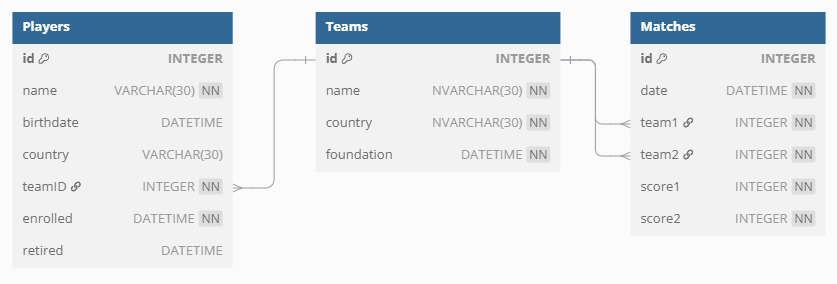

Foundation - дата основания

**Имя команды сделать unique**

# Задание 1
Реализовать таблицы со связями по схеме выше. Добавьте несколько команд и матчей между ними (через INSERT).

In [13]:
import sqlite3
import random
from datetime import datetime, timedelta

# Регистрация адаптеров для datetime (решение проблемы с DeprecationWarning)
def adapt_datetime(dt):
    return dt.isoformat()

def convert_datetime(s):
    return datetime.fromisoformat(s.decode())

# Регистрируем адаптеры
sqlite3.register_adapter(datetime, adapt_datetime)
sqlite3.register_converter("datetime", convert_datetime)
sqlite3.register_converter("timestamp", convert_datetime)

# Подключение к базе данных с detect_types для автоматической конвертации
conn = sqlite3.connect('base.db', detect_types=sqlite3.PARSE_DECLTYPES)
cursor = conn.cursor()

# 1. Создание таблиц со связями
cursor.execute('''
CREATE TABLE IF NOT EXISTS Teams (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name NVARCHAR(30) NOT NULL UNIQUE,
    country NVARCHAR(30) NOT NULL,
    foundation DATETIME NOT NULL
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Players (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name VARCHAR(30) NOT NULL,
    birthdate DATETIME,
    country VARCHAR(30),
    teamID INTEGER NOT NULL,
    enrolled DATETIME NOT NULL,
    retired DATETIME,
    FOREIGN KEY (teamID) REFERENCES Teams(id) ON DELETE CASCADE
)
''')

cursor.execute('''
CREATE TABLE IF NOT EXISTS Matches (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date DATETIME NOT NULL,
    team1 INTEGER NOT NULL,
    team2 INTEGER NOT NULL,
    score1 INTEGER NOT NULL,
    score2 INTEGER NOT NULL,
    FOREIGN KEY (team1) REFERENCES Teams(id) ON DELETE CASCADE,
    FOREIGN KEY (team2) REFERENCES Teams(id) ON DELETE CASCADE,
    CHECK (team1 != team2)
)
''')

# 2. Добавление команд
teams_data = [
    ("Real Madrid", "Spain", datetime(1902, 3, 6)),
    ("FC Barcelona", "Spain", datetime(1899, 11, 29)),
    ("Bayern Munich", "Germany", datetime(1900, 2, 27)),
    ("Paris Saint-Germain", "France", datetime(1970, 8, 12)),
    ("Manchester City", "United Kingdom", datetime(1880, 4, 16)),
    ("Liverpool", "United Kingdom", datetime(1892, 6, 3)),
    ("Juventus", "Italy", datetime(1897, 11, 1)),
    ("AC Milan", "Italy", datetime(1899, 12, 16)),
    ("Ajax", "Netherlands", datetime(1900, 3, 18)),
    ("Borussia Dortmund", "Germany", datetime(1909, 12, 19))
]

for name, country, foundation in teams_data:
    cursor.execute('''
    INSERT OR IGNORE INTO Teams (name, country, foundation)
    VALUES (?, ?, ?)
    ''', (name, country, foundation))

conn.commit()

# 3. Добавление матчей
cursor.execute("SELECT id, name, country, DATE(foundation) FROM Teams")
teams = cursor.fetchall()
team_ids = [team[0] for team in teams]

matches = []
start_date = datetime(2024, 1, 15, 18, 0, 0)  # Добавляем время

for i in range(len(team_ids)):
    for j in range(i + 1, len(team_ids)):
        # Первый матч
        date1 = start_date + timedelta(days=len(matches) % 30)
        score1 = random.randint(0, 5)
        score2 = random.randint(0, 5)
        matches.append((date1, team_ids[i], team_ids[j], score1, score2))

        # Ответный матч
        date2 = date1 + timedelta(days=14)
        score3 = random.randint(0, 5)
        score4 = random.randint(0, 5)
        matches.append((date2, team_ids[j], team_ids[i], score3, score4))

additional_matches = [
    (datetime(2024, 5, 20, 21, 0, 0), team_ids[0], team_ids[1], 3, 1),
    (datetime(2024, 5, 25, 20, 45, 0), team_ids[2], team_ids[3], 2, 2),
    (datetime(2024, 6, 1, 18, 30, 0), team_ids[4], team_ids[5], 1, 0),
    (datetime(2024, 6, 10, 20, 0, 0), team_ids[6], team_ids[7], 2, 1),
    (datetime(2024, 6, 15, 22, 0, 0), team_ids[0], team_ids[8], 4, 2),
    (datetime(2024, 6, 20, 19, 0, 0), team_ids[9], team_ids[1], 1, 3),
]

matches.extend(additional_matches)

for match in matches:
    cursor.execute('''
    INSERT INTO Matches (date, team1, team2, score1, score2)
    VALUES (?, ?, ?, ?, ?)
    ''', match)

conn.commit()

# 4. Добавление игроков
players_data = [
    ("Lionel Messi", datetime(1987, 6, 24), "Argentina", 2, datetime(2021, 8, 10, 12, 0, 0), None),
    ("Cristiano Ronaldo", datetime(1985, 2, 5), "Portugal", 1, datetime(2022, 9, 1, 10, 0, 0), None),
    ("Robert Lewandowski", datetime(1988, 8, 21), "Poland", 3, datetime(2022, 7, 15, 9, 0, 0), None),
    ("Kylian Mbappe", datetime(1998, 12, 20), "France", 4, datetime(2017, 8, 1, 14, 30, 0), None),
    ("Erling Haaland", datetime(2000, 7, 21), "Norway", 5, datetime(2022, 7, 1, 11, 0, 0), None),
    ("Kevin De Bruyne", datetime(1991, 6, 28), "Belgium", 5, datetime(2015, 8, 30, 10, 0, 0), None),
    ("Mohamed Salah", datetime(1992, 6, 15), "Egypt", 6, datetime(2017, 6, 22, 12, 0, 0), None),
]

for name, birthdate, country, teamID, enrolled, retired in players_data:
    cursor.execute('''
    INSERT OR IGNORE INTO Players (name, birthdate, country, teamID, enrolled, retired)
    VALUES (?, ?, ?, ?, ?, ?)
    ''', (name, birthdate, country, teamID, enrolled, retired))

conn.commit()

# 5. Проверка результатов
print("\nTeams")
cursor.execute("SELECT id, name, country, DATE(foundation) FROM Teams")
for row in cursor.fetchall():
    print(f"ID: {row[0]}, Name: {row[1]}, Country: {row[2]}, Foundation: {row[3]}")

print("\nMatches")
cursor.execute('''
SELECT m.id, DATE(m.date), t1.name, t2.name, m.score1, m.score2
FROM Matches m
JOIN Teams t1 ON m.team1 = t1.id
JOIN Teams t2 ON m.team2 = t2.id
LIMIT 10
''')
for row in cursor.fetchall():
    print(f"Match {row[0]}: {row[2]} {row[4]}:{row[5]} {row[3]} ({row[1]})")

cursor.execute("SELECT COUNT(*) FROM Matches")

print("\nPlayers")
cursor.execute('''
SELECT p.name, p.country, t.name as team, DATE(p.enrolled), DATE(p.birthdate)
FROM Players p
JOIN Teams t ON p.teamID = t.id
LIMIT 10
''')
for row in cursor.fetchall():
    print(f"{row[0]} ({row[1]}) - {row[2]}, enrolled: {row[3]}, born: {row[4]}")

conn.commit()
# Закрытие соединения
conn.close()


Teams
ID: 1, Name: Real Madrid, Country: Spain, Foundation: 1902-03-06
ID: 2, Name: FC Barcelona, Country: Spain, Foundation: 1899-11-29
ID: 3, Name: Bayern Munich, Country: Germany, Foundation: 1900-02-27
ID: 4, Name: Paris Saint-Germain, Country: France, Foundation: 1970-08-12
ID: 5, Name: Manchester City, Country: United Kingdom, Foundation: 1880-04-16
ID: 6, Name: Liverpool, Country: United Kingdom, Foundation: 1892-06-03
ID: 7, Name: Juventus, Country: Italy, Foundation: 1897-11-01
ID: 8, Name: AC Milan, Country: Italy, Foundation: 1899-12-16
ID: 9, Name: Ajax, Country: Netherlands, Foundation: 1900-03-18
ID: 10, Name: Borussia Dortmund, Country: Germany, Foundation: 1909-12-19

Matches
Match 1: Real Madrid 4:4 FC Barcelona (2024-01-15)
Match 2: FC Barcelona 1:2 Real Madrid (2024-01-29)
Match 3: Real Madrid 1:4 Bayern Munich (2024-01-17)
Match 4: Bayern Munich 3:5 Real Madrid (2024-01-31)
Match 5: Real Madrid 2:5 Paris Saint-Germain (2024-01-19)
Match 6: Paris Saint-Germain 3:5 R

# Задание 2

Написать функцию, осуществляющую добавление нового игрока в таблицу игроков.

На входе имя, дата рождения, страна, **имя команды**, дата перехода в команду, дата увольнения (необязательный параметр). Предусмотреть различные ошибки (такие как неверное название команды (игрока нельзя добавить, если его команды нет в таблице команд), возраст < 0 и т.п.)

После написания функции необходимо добавить несколько игроков.

In [11]:
import sqlite3
from datetime import datetime, date

def adapt_datetime(dt):
    return dt.isoformat()

def convert_datetime(s):
    return datetime.fromisoformat(s.decode())

# Регистрируем адаптеры
sqlite3.register_adapter(datetime, adapt_datetime)
sqlite3.register_converter("datetime", convert_datetime)

def add_player(name, birthdate, country, team_name, enrolled_date, retired_date=None):
    # Подключаемся к БД
    conn = None
    try:
        conn = sqlite3.connect('base.db', detect_types=sqlite3.PARSE_DECLTYPES)
        cursor = conn.cursor()

        # 1. Проверка обязательных параметров
        if not name or not isinstance(name, str) or name.strip() == "":
            raise ValueError("Ошибка: Имя игрока обязательно")

        if not country or not isinstance(country, str):
            raise ValueError("Ошибка: Страна игрока обязательна")

        # 2. Проверка и конвертация дат
        if isinstance(birthdate, str):
            birthdate = datetime.strptime(birthdate, '%Y-%m-%d')

        if isinstance(enrolled_date, str):
            enrolled_date = datetime.strptime(enrolled_date, '%Y-%m-%d')

        if retired_date and isinstance(retired_date, str):
            retired_date = datetime.strptime(retired_date, '%Y-%m-%d')

        # 3. Проверка возраста
        today = datetime.now()
        age = today.year - birthdate.year - ((today.month, today.day) < (birthdate.month, birthdate.day))

        if age < 0:
            raise ValueError("Ошибка: Дата рождения не может быть в будущем")

        if age > 100:
            raise ValueError(f"Ошибка: Слишком большой возраст ({age} лет)")

        if age < 14:
            raise ValueError(f"Ошибка: Игрок слишком молод ({age} лет). Минимальный возраст - 14 лет")

        # 4. Проверка логики дат
        if retired_date and retired_date <= enrolled_date:
            raise ValueError("Ошибка: Дата увольнения должна быть позже даты перехода")

        if retired_date and retired_date > today:
            raise ValueError("Ошибка: Дата увольнения не может быть в будущем")

        if enrolled_date > today:
            raise ValueError("Ошибка: Дата перехода не может быть в будущем")

        # 5. Проверка существования команды
        cursor.execute("SELECT id FROM Teams WHERE name = ?", (team_name,))
        team = cursor.fetchone()

        if not team:
            raise ValueError(f"Ошибка: Команда '{team_name}' не найдена")

        team_id = team[0]

        # 6. Проверка на дубликат (учитываем только активных игроков)
        cursor.execute('''
            SELECT id FROM Players
            WHERE name = ? AND teamID = ? AND retired IS NULL
        ''', (name, team_id))

        existing_player = cursor.fetchone()
        if existing_player:
            raise ValueError(f"Ошибка: Игрок '{name}' уже числится в команде '{team_name}'")

        # 7. Добавление игрока
        cursor.execute('''
            INSERT INTO Players (name, birthdate, country, teamID, enrolled, retired)
            VALUES (?, ?, ?, ?, ?, ?)
        ''', (name.strip(), birthdate, country, team_id, enrolled_date, retired_date))

        conn.commit()
        player_id = cursor.lastrowid

        print(f"Игрок '{name}' успешно добавлен в команду '{team_name}' (ID: {player_id})")
        return player_id

    except ValueError as e:
        print(f"{e}")
        return None
    except Exception as e:
        print(f"Ошибка: {e}")
        return None
    finally:
        if conn:
            conn.close()


def safe_add_player(name, birthdate, country, team_name, enrolled_date, retired_date=None):
    print(f"\nИгрок: {name}")
    print(f"команда={team_name}, страна={country}, дата перехода={enrolled_date}")
    if retired_date:
        print(f"Дата увольнения={retired_date}")

    result = add_player(name, birthdate, country, team_name, enrolled_date, retired_date)
    if result:
        print(f"успешно, ID={result}")
    else:
        print(f"ошибка")
    return result


if __name__ == "__main__":

    # ОЧИСТКА ТАБЛИЦЫ ИГРОКОВ перед добавлением
    conn = sqlite3.connect('base.db')
    cursor = conn.cursor()
    cursor.execute("DELETE FROM Players")  # Удаляем всех старых игроков
    conn.commit()
    conn.close()
    print("Таблица Players очищена\n")

    # 1. добавление игрока
    safe_add_player(
        name="Vinicius Junior",
        birthdate="2000-07-12",
        country="Brazil",
        team_name="Real Madrid",
        enrolled_date="2018-07-20"
    )

    # 2. добавление с указанием даты увольнения
    safe_add_player(
        name="Gareth Bale",
        birthdate="1989-07-16",
        country="Wales",
        team_name="Real Madrid",
        enrolled_date="2013-09-01",
        retired_date="2022-06-30"
    )

    # 3. добавление в другую команду
    safe_add_player(
        name="Phil Foden",
        birthdate="2000-05-28",
        country="England",
        team_name="Manchester City",
        enrolled_date="2017-07-01"
    )

    # 4. добавление с использованием datetime объектов
    safe_add_player(
        name="Jamal Musiala",
        birthdate=datetime(2003, 2, 26),
        country="Germany",
        team_name="Bayern Munich",
        enrolled_date=datetime(2020, 7, 1)
    )

    # 5. Несуществующая команда
    safe_add_player(
        name="Test Player",
        birthdate="1995-01-01",
        country="Testland",
        team_name="Non Existent Team",
        enrolled_date="2020-01-01"
    )

    # 6. Отрицательный возраст
    safe_add_player(
        name="Future Player",
        birthdate="2030-01-01",
        country="Futureland",
        team_name="Real Madrid",
        enrolled_date="2024-01-01"
    )

    # 7. Слишком молодой игрок
    safe_add_player(
        name="Young Player",
        birthdate="2020-01-01",
        country="Youngland",
        team_name="Barcelona",
        enrolled_date="2024-01-01"
    )

    # 8. Дата перехода в будущем
    safe_add_player(
        name="Future Transfer",
        birthdate="1995-01-01",
        country="Futureland",
        team_name="Liverpool",
        enrolled_date="2025-06-01"
    )

    # 9. Дата увольнения раньше даты перехода
    safe_add_player(
        name="Wrong Dates",
        birthdate="1990-01-01",
        country="Errorland",
        team_name="Juventus",
        enrolled_date="2020-01-01",
        retired_date="2019-12-31"
    )

    # 10. Дубликат активного игрока
    safe_add_player(
        name="Vinicius Junior",
        birthdate="2000-07-12",
        country="Brazil",
        team_name="Real Madrid",
        enrolled_date="2023-01-01"
    )

    # 11. Пустое имя
    safe_add_player(
        name="",
        birthdate="1995-01-01",
        country="Testland",
        team_name="Real Madrid",
        enrolled_date="2020-01-01"
    )


    conn = sqlite3.connect('base.db', detect_types=sqlite3.PARSE_DECLTYPES)
    cursor = conn.cursor()

    conn.close()

Таблица Players очищена


Игрок: Vinicius Junior
команда=Real Madrid, страна=Brazil, дата перехода=2018-07-20
Игрок 'Vinicius Junior' успешно добавлен в команду 'Real Madrid' (ID: 63)
успешно, ID=63

Игрок: Gareth Bale
команда=Real Madrid, страна=Wales, дата перехода=2013-09-01
Дата увольнения=2022-06-30
Игрок 'Gareth Bale' успешно добавлен в команду 'Real Madrid' (ID: 64)
успешно, ID=64

Игрок: Phil Foden
команда=Manchester City, страна=England, дата перехода=2017-07-01
Игрок 'Phil Foden' успешно добавлен в команду 'Manchester City' (ID: 65)
успешно, ID=65

Игрок: Jamal Musiala
команда=Bayern Munich, страна=Germany, дата перехода=2020-07-01 00:00:00
Игрок 'Jamal Musiala' успешно добавлен в команду 'Bayern Munich' (ID: 66)
успешно, ID=66

Игрок: Test Player
команда=Non Existent Team, страна=Testland, дата перехода=2020-01-01
Ошибка: Команда 'Non Existent Team' не найдена
ошибка

Игрок: Future Player
команда=Real Madrid, страна=Futureland, дата перехода=2024-01-01
Ошибка: Дата рождения 

# Задание 3
Написать функцию player_stat, которая получает на вход имя игрока и выдает количество побед, ничей и поражений этого игрока (учитывать, что до и после найма игрока успехи его команды не учитываются).
Вывести статистику по игрокам.

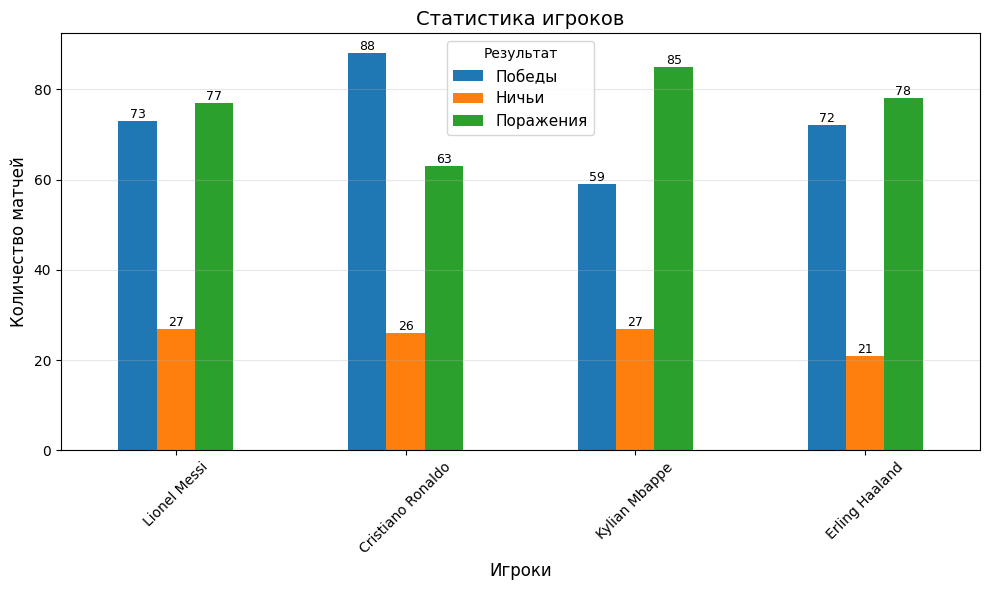

In [16]:
import sqlite3
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

def player_stat(player_name):
    conn = sqlite3.connect('base.db')
    cursor = conn.cursor()

    # Получаем данные игрока
    cursor.execute('''
        SELECT teamID, enrolled, retired FROM Players WHERE name = ?
    ''', (player_name,))

    player = cursor.fetchone()
    if not player:
        print(f"Игрок '{player_name}' не найден")
        conn.close()
        return None

    team_id, enrolled, retired = player
    end_date = retired if retired else datetime.now().strftime('%Y-%m-%d')

    # Получаем матчи команды за период
    cursor.execute('''
        SELECT team1, team2, score1, score2 FROM Matches
        WHERE (team1 = ? OR team2 = ?) AND date BETWEEN ? AND ?
    ''', (team_id, team_id, enrolled, end_date))

    matches = cursor.fetchall()
    conn.close()


    wins = 0
    draws = 0
    losses = 0

    for match in matches:
        team1, team2, score1, score2 = match

        if team1 == team_id:
            our_score, their_score = score1, score2
        else:
            our_score, their_score = score2, score1

        if our_score > their_score:
            wins += 1
        elif our_score == their_score:
            draws += 1
        else:
            losses += 1

    return wins, draws, losses

# Построение графика
if wins_list:
    df = pd.DataFrame({
        'Победы': wins_list,
        'Ничьи': draws_list,
        'Поражения': losses_list
    }, index=players)

    ax = df.plot.bar(rot=45, figsize=(10, 6))
    ax.set_xlabel('Игроки', fontsize=12)
    ax.set_ylabel('Количество матчей', fontsize=12)
    ax.set_title('Статистика игроков', fontsize=14)
    ax.legend(title='Результат', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Добавление значений на столбцы
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("Нет данных")

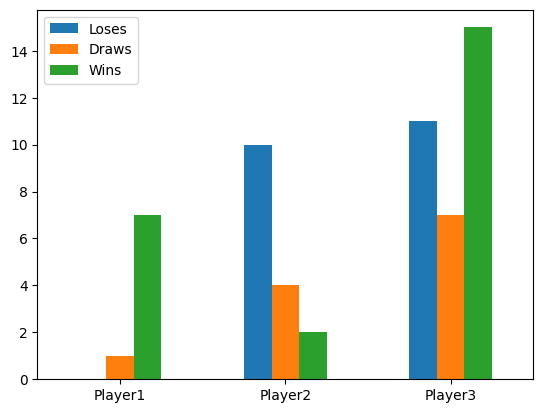

In [ ]:
#Пример статистики
import matplotlib.pyplot as plt
import pandas as pd

players = ['Player1','Player2','Player3']
wins = [7, 2, 15]
draws = [1, 4, 7]
loses = [0, 10, 11]

df = pd.DataFrame({'Loses': loses, 'Draws': draws, 'Wins': wins}, index=players)
ax = df.plot.bar(rot=0)